In [ ]:
import os, json, math, random, time
from dataclasses import dataclass
from typing import Dict, Tuple
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from safetensors.torch import save_file as save_safetensors


# -----------------------------
# Config
# -----------------------------
@dataclass
class TrainCfg:
    p: int = 113                 # modulus
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    d_ff: int = 256
    dropout: float = 0.0

    batch_size: int = 32
    steps: int = 5_000
    lr: float = 1e-3
    weight_decay: float = 0.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    snapshot_every: int = 200
    eval_every: int = 200        # <<< 新增：每隔多少 step 做一次 eval
    test_size: int = 20_000      # <<< 新增：test set size（不想用全 p^2 就采样）
    out_dir: str = "./runs/modadd_1"


def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------------
# Data: modular addition
# -----------------------------
@torch.no_grad()
def sample_batch(p: int, batch_size: int, device: str):
    a = torch.randint(0, p, (batch_size,), device=device)
    b = torch.randint(0, p, (batch_size,), device=device)
    y = (a + b) % p
    return a, b, y


@torch.no_grad()
def make_test_set(p: int, test_size: int, device: str):
    # 固定一个 test set，保证每次评估一致
    a = torch.randint(0, p, (test_size,), device=device)
    b = torch.randint(0, p, (test_size,), device=device)
    y = (a + b) % p
    return a, b, y


@torch.no_grad()
def eval_model(model: nn.Module, a: torch.Tensor, b: torch.Tensor, y: torch.Tensor, batch_size: int = 2048):
    """
    返回 test_loss, test_acc
    """
    model.eval()
    n = a.shape[0]
    total_loss = 0.0
    total_correct = 0

    for i in range(0, n, batch_size):
        aa = a[i:i+batch_size]
        bb = b[i:i+batch_size]
        yy = y[i:i+batch_size]
        logits = model(aa, bb)
        loss = F.cross_entropy(logits, yy, reduction="sum")
        total_loss += loss.item()
        pred = logits.argmax(dim=-1)
        total_correct += (pred == yy).sum().item()

    test_loss = total_loss / n
    test_acc = total_correct / n
    return test_loss, test_acc


# -----------------------------
# Model
# -----------------------------
class ModAddTransformer(nn.Module):
    def __init__(self, p: int, d_model: int, n_heads: int, n_layers: int, d_ff: int, dropout: float):
        super().__init__()
        self.tok_emb = nn.Embedding(p, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(2, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, a: torch.Tensor, b: torch.Tensor):
        x = torch.stack([a, b], dim=1)              # (B, 2)
        h = self.tok_emb(x) + self.pos_emb          # (B, 2, d)
        h = self.encoder(h)                         # (B, 2, d)
        h = self.ln(h[:, 1, :])                     # (B, d)
        logits = self.head(h)                       # (B, p)
        return logits


# -----------------------------
# Snapshot helpers
# -----------------------------
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def to_cpu_fp32_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    sd = model.state_dict()
    out = {}
    for k, v in sd.items():
        if not torch.is_floating_point(v):
            continue
        out[k] = v.detach().to(dtype=torch.float32, device="cpu").contiguous()
    return out

def save_snapshot(
    *,
    out_dir: str,
    step: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    meta: dict,
    save_checkpoint: bool = True,
    save_weights_safetensors: bool = True,
):
    ensure_dir(out_dir)
    tag = f"step_{step:07d}"
    snap_dir = os.path.join(out_dir, "snapshots")
    ensure_dir(snap_dir)

    # 1) checkpoint
    if save_checkpoint:
        ckpt_path = os.path.join(snap_dir, f"{tag}.pt")
        payload = {
            "meta": meta,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
        }
        torch.save(payload, ckpt_path)

    # 2) safetensors
    if save_weights_safetensors:
        w_path = os.path.join(snap_dir, f"{tag}.safetensors")
        cpu_sd = to_cpu_fp32_state_dict(model)
        save_safetensors(cpu_sd, w_path, metadata={k: str(v) for k, v in meta.items()})

    # 3) manifest
    manifest_path = os.path.join(out_dir, "manifest.jsonl")
    with open(manifest_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(meta) + "\n")


# -----------------------------
# Train loop
# -----------------------------
def train(cfg: TrainCfg, seed: int = 0):
    set_seed(seed)
    ensure_dir(cfg.out_dir)

    model = ModAddTransformer(
        p=cfg.p,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(cfg.device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    # fixed test set
    test_a, test_b, test_y = make_test_set(cfg.p, cfg.test_size, cfg.device)

    # logs for plotting
    steps_log = []
    train_loss_log = []
    test_loss_log = []

    model.train()
    for step in range(1, cfg.steps + 1):
        a, b, y = sample_batch(cfg.p, cfg.batch_size, cfg.device)
        logits = model(a, b)
        train_loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        train_loss.backward()
        optimizer.step()

        if (step % cfg.eval_every) == 0 or step == 1:
            test_loss, test_acc = eval_model(model, test_a, test_b, test_y)

            # store logs
            steps_log.append(step)
            train_loss_log.append(train_loss.item())
            test_loss_log.append(test_loss)

            print(
                f"[step {step:6d}] "
                f"train_loss={train_loss.item():.6f} "
                f"test_loss={test_loss:.6f} "
                f"test_acc={test_acc*100:.2f}%"
            )

            model.train()

        if (step % cfg.snapshot_every) == 0 or step == 1:
            meta = {
                "step": step,
                "seed": seed,
                "train_loss": float(train_loss.item()),
            }
            if (step % cfg.eval_every) == 0 or step == 1:
                meta["test_loss"] = float(test_loss)
                meta["test_acc"] = float(test_acc)

            save_snapshot(
                out_dir=cfg.out_dir,
                step=step,
                model=model,
                optimizer=optimizer,
                meta=meta,
                save_checkpoint=True,
                save_weights_safetensors=True,
            )

    # -------- plot & save --------
    plt.figure()
    plt.plot(steps_log, train_loss_log, label="train loss")
    plt.plot(steps_log, test_loss_log, label="test loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training vs Test Loss")
    plt.legend()
    plt.grid(True)

    out_path = os.path.join(cfg.out_dir, "loss_curve.png")
    plt.savefig(out_path, dpi=200)
    print(f"Saved loss plot to: {out_path}")


/opt/anaconda3/envs/env_01/lib/python3.10/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


[step      1] train_loss=4.809330 test_loss=4.890470 test_acc=0.94%
[step    200] train_loss=4.667807 test_loss=4.816181 test_acc=1.99%
[step    400] train_loss=4.834918 test_loss=4.774751 test_acc=2.47%
[step    600] train_loss=4.678406 test_loss=4.737192 test_acc=2.42%
[step    800] train_loss=4.690414 test_loss=4.707213 test_acc=2.93%
[step   1000] train_loss=4.865358 test_loss=4.681271 test_acc=3.79%
[step   1200] train_loss=4.658486 test_loss=4.620914 test_acc=4.74%
[step   1400] train_loss=4.324486 test_loss=4.525430 test_acc=5.78%
[step   1600] train_loss=4.216591 test_loss=4.412294 test_acc=7.21%
[step   1800] train_loss=3.676234 test_loss=4.016167 test_acc=10.05%
[step   2000] train_loss=3.404734 test_loss=3.214454 test_acc=16.02%
[step   2200] train_loss=2.580946 test_loss=2.554833 test_acc=25.89%
[step   2400] train_loss=1.855558 test_loss=1.956452 test_acc=36.93%
[step   2600] train_loss=1.506496 test_loss=1.422867 test_acc=55.71%
[step   2800] train_loss=0.806556 test_loss

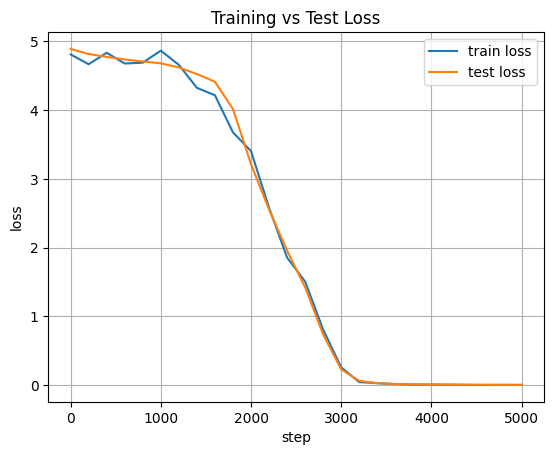

In [6]:
cfg = TrainCfg()
train(cfg, seed=0)

In [3]:
cfg = TrainCfg()
train(cfg, seed=0)

/opt/anaconda3/envs/env_01/lib/python3.10/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


[step      1] train_loss=4.882706 test_loss=4.888826 test_acc=0.95% time=0.3s
[step    200] train_loss=4.563113 test_loss=4.564334 test_acc=5.17% time=3.1s
[step    400] train_loss=2.353311 test_loss=2.416799 test_acc=44.75% time=6.2s
[step    600] train_loss=0.235417 test_loss=0.258148 test_acc=96.96% time=9.2s
[step    800] train_loss=0.027083 test_loss=0.026708 test_acc=99.99% time=12.0s
[step   1000] train_loss=0.011120 test_loss=0.011341 test_acc=100.00% time=14.8s
[step   1200] train_loss=0.006951 test_loss=0.006703 test_acc=100.00% time=18.0s
[step   1400] train_loss=0.004444 test_loss=0.004447 test_acc=100.00% time=20.9s
[step   1600] train_loss=0.003341 test_loss=0.003163 test_acc=100.00% time=23.7s
[step   1800] train_loss=0.002316 test_loss=0.002361 test_acc=100.00% time=26.6s
[step   2000] train_loss=0.001907 test_loss=0.001825 test_acc=100.00% time=29.4s
[step   2200] train_loss=0.001398 test_loss=0.001438 test_acc=100.00% time=32.4s
[step   2400] train_loss=0.001156 test_

In [ ]:

# -----------------------------
# Config
# -----------------------------
@dataclass
class TrainCfg():
    p: int = 113                 # modulus
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    d_ff: int = 512
    dropout: float = 0.0

    # grokking-critical:
    train_frac: float = 0.03      # <<< must be < 1
    steps: int = 1000_000        # <<< grokking often needs long training
    batch_size: int = 1024
    lr: float = 3e-3
    weight_decay: float = 5e-2   # <<< grokking often needs AdamW weight decay

    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    eval_every: int = 2000        # eval on full train/test splits
    snapshot_every: int = 2000   # store weights for TDA
    out_dir: str = "./runs/modadd_grokking"

    
    def __str__(self):
        return json.dumps(self.__dict__, indent=2)


def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------------
# Dataset: all pairs + split
# -----------------------------
@torch.no_grad()
def make_full_dataset(p: int, device: str) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # all (a,b) pairs, size p^2
    a = torch.arange(p, device=device).repeat_interleave(p)  # (p^2,)
    b = torch.arange(p, device=device).repeat(p)             # (p^2,)
    y = (a + b) % p
    return a, b, y

@torch.no_grad()
def split_dataset(a, b, y, train_frac: float, seed: int):
    n = a.shape[0]
    g = torch.Generator(device=a.device).manual_seed(seed)
    perm = torch.randperm(n, generator=g, device=a.device)
    n_train = int(train_frac * n)
    idx_tr = perm[:n_train]
    idx_te = perm[n_train:]
    return (a[idx_tr], b[idx_tr], y[idx_tr]), (a[idx_te], b[idx_te], y[idx_te])

def sample_from_split(a, b, y, batch_size: int):
    idx = torch.randint(0, a.shape[0], (batch_size,), device=a.device)
    return a[idx], b[idx], y[idx]


# -----------------------------
# Model
# -----------------------------
class ModAddTransformer(nn.Module):
    def __init__(self, p: int, d_model: int, n_heads: int, n_layers: int, d_ff: int, dropout: float):
        super().__init__()
        self.tok_emb = nn.Embedding(p, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(2, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, a: torch.Tensor, b: torch.Tensor):
        x = torch.stack([a, b], dim=1)              # (B, 2)
        h = self.tok_emb(x) + self.pos_emb          # (B, 2, d)
        h = self.encoder(h)                         # (B, 2, d)
        h = self.ln(h[:, 1, :])                     # (B, d)
        logits = self.head(h)                       # (B, p)
        return logits


# -----------------------------
# Eval (full split)
# -----------------------------
@torch.no_grad()
def eval_split(model: nn.Module, a: torch.Tensor, b: torch.Tensor, y: torch.Tensor, batch_size: int = 8192):
    model.eval()
    n = a.shape[0]
    total_loss = 0.0
    total_correct = 0

    for i in range(0, n, batch_size):
        aa = a[i:i+batch_size]
        bb = b[i:i+batch_size]
        yy = y[i:i+batch_size]
        logits = model(aa, bb)
        loss = F.cross_entropy(logits, yy, reduction="sum")
        total_loss += loss.item()
        pred = logits.argmax(dim=-1)
        total_correct += (pred == yy).sum().item()

    return total_loss / n, total_correct / n


# -----------------------------
# Snapshot helpers
# -----------------------------
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def to_cpu_fp32_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    sd = model.state_dict()
    out = {}
    for k, v in sd.items():
        if not torch.is_floating_point(v):
            continue
        out[k] = v.detach().to(dtype=torch.float32, device="cpu").contiguous()
    return out

def save_snapshot(
    *,
    out_dir: str,
    step: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    meta: dict,
    save_checkpoint: bool = True,
    save_weights_safetensors: bool = True,
):
    ensure_dir(out_dir)
    tag = f"step_{step:07d}"
    snap_dir = os.path.join(out_dir, "snapshots")
    ensure_dir(snap_dir)

    if save_checkpoint:
        ckpt_path = os.path.join(snap_dir, f"{tag}.pt")
        torch.save(
            {"meta": meta, "model": model.state_dict(), "optimizer": optimizer.state_dict()},
            ckpt_path
        )

    if save_weights_safetensors:
        w_path = os.path.join(snap_dir, f"{tag}.safetensors")
        cpu_sd = to_cpu_fp32_state_dict(model)
        save_safetensors(cpu_sd, w_path, metadata={k: str(v) for k, v in meta.items()})

    manifest_path = os.path.join(out_dir, "manifest.jsonl")
    with open(manifest_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(meta) + "\n")


# -----------------------------
# Train loop + plotting
# -----------------------------
def train(cfg: TrainCfg, seed: int = 0):
    set_seed(seed)
    ensure_dir(cfg.out_dir)

    model = ModAddTransformer(
        p=cfg.p,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(cfg.device)
    print("torch.cuda.is_available:", torch.cuda.is_available())
    print("cfg.device:", cfg.device)
    print("model device:", next(model.parameters()).device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    # fixed full dataset + split
    full_a, full_b, full_y = make_full_dataset(cfg.p, cfg.device)
    (tr_a, tr_b, tr_y), (te_a, te_b, te_y) = split_dataset(full_a, full_b, full_y, cfg.train_frac, seed=seed)

    print(f"dataset: total={full_a.numel()} train={tr_a.numel()} test={te_a.numel()}")

    # logs
    steps_log, tr_loss_log, te_loss_log = [], [], []
    tr_acc_log, te_acc_log = [], []

    t0 = time.time()
    model.train()

    for step in range(1, cfg.steps + 1):
        a, b, y = sample_from_split(tr_a, tr_b, tr_y, cfg.batch_size)

        logits = model(a, b)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        do_eval = (step % cfg.eval_every == 0) or (step == 1)
        if do_eval:
            tr_loss, tr_acc = eval_split(model, tr_a, tr_b, tr_y)
            te_loss, te_acc = eval_split(model, te_a, te_b, te_y)

            steps_log.append(step)
            tr_loss_log.append(tr_loss)
            te_loss_log.append(te_loss)
            tr_acc_log.append(tr_acc)
            te_acc_log.append(te_acc)

            elapsed = time.time() - t0
            print(
                f"[step {step:7d}] "
                f"train_loss={tr_loss:.6f} train_acc={tr_acc*100:.2f}% | "
                f"test_loss={te_loss:.6f} test_acc={te_acc*100:.2f}% | "
                f"time={elapsed:.1f}s"
            )

            model.train()

        do_snap = (step % cfg.snapshot_every == 0) or (step == 1)
        if do_snap:
            meta = {
                "step": step,
                "seed": seed,
                "wallclock_sec": float(time.time() - t0),
                "train_frac": cfg.train_frac,
                "lr": cfg.lr,
                "weight_decay": cfg.weight_decay,
            }
            if do_eval:
                meta.update({
                    "train_loss": float(tr_loss),
                    "train_acc": float(tr_acc),
                    "test_loss": float(te_loss),
                    "test_acc": float(te_acc),
                })
            save_snapshot(
                out_dir=cfg.out_dir,
                step=step,
                model=model,
                optimizer=optimizer,
                meta=meta,
                save_checkpoint=True,
                save_weights_safetensors=True,
            )

    # ---- plots ----
    # loss
    plt.figure()
    plt.plot(steps_log, tr_loss_log, label="train loss (full train split)")
    plt.plot(steps_log, te_loss_log, label="test loss (full test split)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Grokking setup: loss vs training step")
    plt.legend()
    plt.grid(True)
    loss_path = os.path.join(cfg.out_dir, "loss_curve.png")
    plt.savefig(loss_path, dpi=200)

    # accuracy (often the grokking jump is clearer here)
    plt.figure()
    plt.plot(steps_log, tr_acc_log, label="train acc")
    plt.plot(steps_log, te_acc_log, label="test acc")
    plt.xlabel("step")
    plt.ylabel("accuracy")
    plt.title("Grokking setup: accuracy vs training step")
    plt.legend()
    plt.grid(True)
    acc_path = os.path.join(cfg.out_dir, "acc_curve.png")
    plt.savefig(acc_path, dpi=200)

    print(f"Saved: {loss_path}")
    print(f"Saved: {acc_path}")




c:\Users\tangy\.conda\envs\env_01\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.cuda.is_available: True
cfg.device: cuda
model device: cuda:0
dataset: total=12769 train=383 test=12386
[step       1] train_loss=4.351682 train_acc=11.75% | test_loss=4.907765 test_acc=0.73% | time=0.2s
[step    2000] train_loss=0.000189 train_acc=100.00% | test_loss=8.762598 test_acc=0.09% | time=15.0s
[step    4000] train_loss=0.000060 train_acc=100.00% | test_loss=9.210055 test_acc=0.13% | time=29.9s
[step    6000] train_loss=0.000592 train_acc=100.00% | test_loss=12.938544 test_acc=0.84% | time=44.4s
[step    8000] train_loss=0.000208 train_acc=100.00% | test_loss=11.751036 test_acc=0.68% | time=58.9s
[step   10000] train_loss=0.000065 train_acc=100.00% | test_loss=11.761303 test_acc=0.55% | time=73.3s
[step   12000] train_loss=0.000019 train_acc=100.00% | test_loss=12.695529 test_acc=0.40% | time=87.9s
[step   14000] train_loss=0.000005 train_acc=100.00% | test_loss=14.182164 test_acc=0.33% | time=102.5s
[step   16000] train_loss=0.000525 train_acc=100.00% | test_loss=15.16

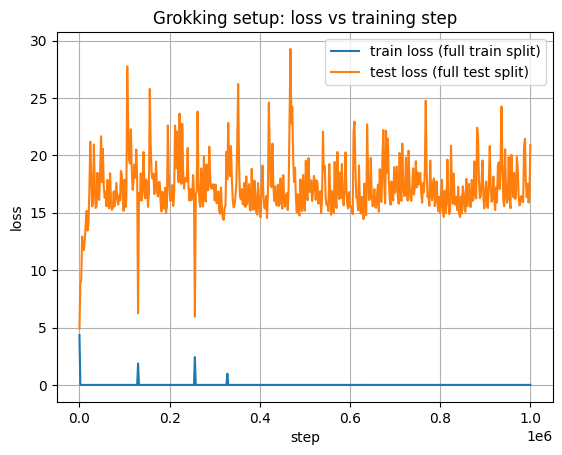

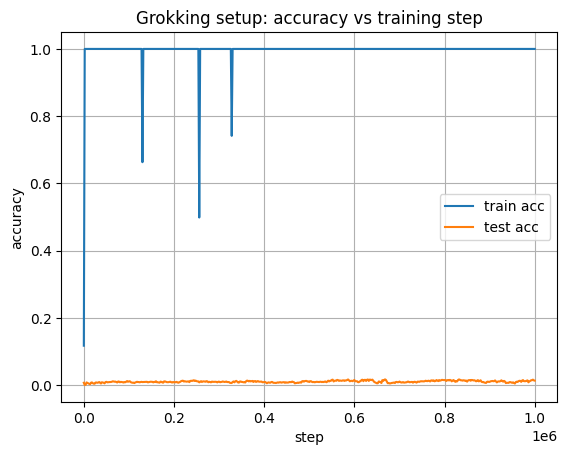

In [9]:
cfg = TrainCfg()
train(cfg, seed=0)

In [16]:
cfg_02 = TrainCfg(train_frac=0.3, steps=500_000, batch_size=512, d_ff=256, weight_decay=0.1, out_dir="./runs/modadd_grokking_02")
print(cfg_02)

{
  "p": 113,
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 2,
  "d_ff": 256,
  "dropout": 0.0,
  "train_frac": 0.3,
  "steps": 500000,
  "batch_size": 512,
  "lr": 0.003,
  "weight_decay": 0.1,
  "device": "cuda",
  "eval_every": 2000,
  "snapshot_every": 2000,
  "out_dir": "./runs/modadd_grokking_02"
}


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.cuda.is_available: True
cfg.device: cuda
model device: cuda:0
dataset: total=12769 train=3830 test=8939
[step       1] train_loss=4.855826 train_acc=1.12% | test_loss=4.904489 test_acc=0.82% | time=0.2s
[step    2000] train_loss=0.003013 train_acc=100.00% | test_loss=10.803906 test_acc=1.58% | time=16.4s
[step    4000] train_loss=0.001107 train_acc=100.00% | test_loss=9.369366 test_acc=1.10% | time=32.2s
[step    6000] train_loss=0.008840 train_acc=99.95% | test_loss=13.020249 test_acc=2.57% | time=47.9s
[step    8000] train_loss=0.001966 train_acc=100.00% | test_loss=10.878403 test_acc=1.71% | time=63.7s
[step   10000] train_loss=0.004054 train_acc=100.00% | test_loss=10.363382 test_acc=3.65% | time=79.2s
[step   12000] train_loss=0.004042 train_acc=100.00% | test_loss=8.821124 test_acc=6.05% | time=94.8s
[step   14000] train_loss=0.006598 train_acc=100.00% | test_loss=7.293681 test_acc=11.58% | time=110.4s
[step   16000] train_loss=0.001615 train_acc=100.00% | test_loss=6.20065

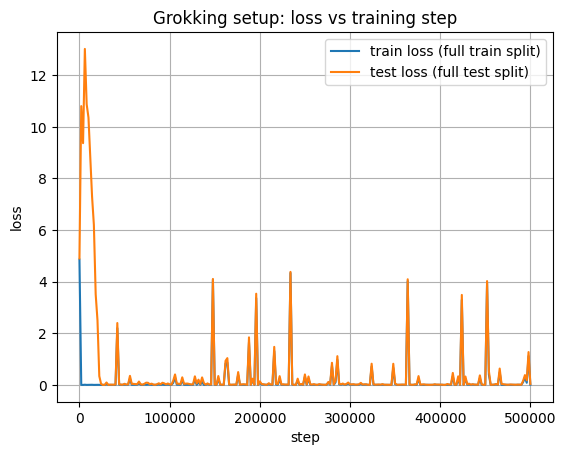

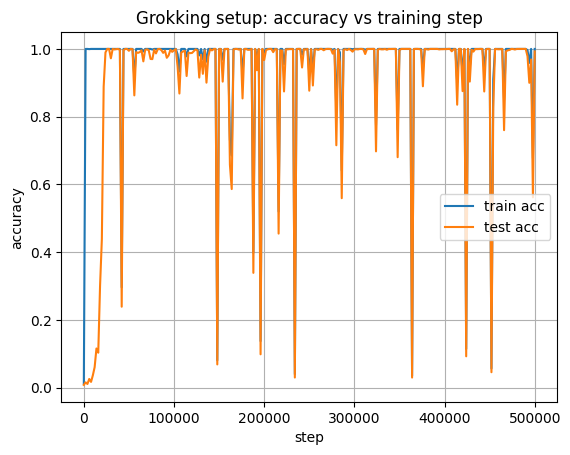

In [17]:
train(cfg_02, seed=0)

In [19]:
cfg_03 = TrainCfg(train_frac=0.2, steps=100_000, batch_size=512, d_ff=256, weight_decay=0.1, eval_every=500, snapshot_every=500, out_dir="./runs/modadd_grokking_03")
print(cfg_03)

{
  "p": 113,
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 2,
  "d_ff": 256,
  "dropout": 0.0,
  "train_frac": 0.2,
  "steps": 100000,
  "batch_size": 512,
  "lr": 0.003,
  "weight_decay": 0.1,
  "device": "cuda",
  "eval_every": 500,
  "snapshot_every": 500,
  "out_dir": "./runs/modadd_grokking_03"
}


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.cuda.is_available: True
cfg.device: cuda
model device: cuda:0
dataset: total=12769 train=2553 test=10216
[step       1] train_loss=4.821149 train_acc=1.68% | test_loss=4.909133 test_acc=0.80% | time=0.2s
[step     500] train_loss=0.003441 train_acc=100.00% | test_loss=8.792019 test_acc=0.51% | time=4.3s
[step    1000] train_loss=0.001783 train_acc=100.00% | test_loss=8.411563 test_acc=0.62% | time=8.4s
[step    1500] train_loss=0.001169 train_acc=100.00% | test_loss=8.057245 test_acc=0.74% | time=12.3s
[step    2000] train_loss=0.000853 train_acc=100.00% | test_loss=7.800872 test_acc=1.19% | time=16.5s
[step    2500] train_loss=0.004002 train_acc=100.00% | test_loss=12.307698 test_acc=1.40% | time=20.9s
[step    3000] train_loss=0.002914 train_acc=100.00% | test_loss=11.159721 test_acc=1.17% | time=24.9s
[step    3500] train_loss=0.002265 train_acc=100.00% | test_loss=10.541480 test_acc=0.99% | time=28.7s
[step    4000] train_loss=0.001555 train_acc=100.00% | test_loss=10.137122 

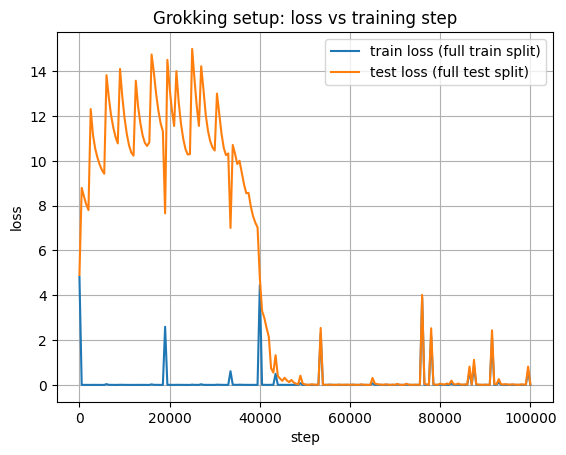

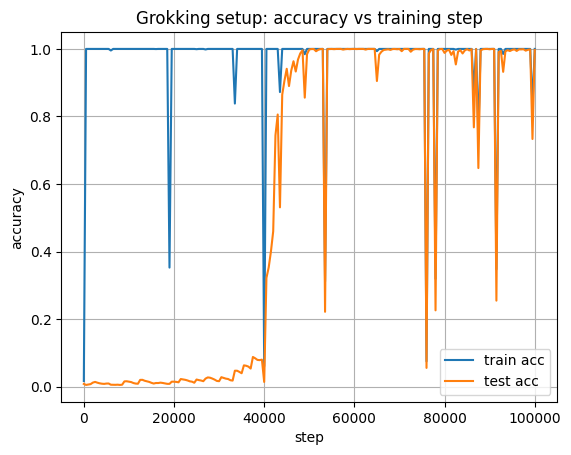

In [20]:
train(cfg_03, seed=0)

In [25]:
def train2(cfg: TrainCfg, seed: int = 0):
    set_seed(seed)
    ensure_dir(cfg.out_dir)

    model = ModAddTransformer(
        p=cfg.p,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(cfg.device)
    print("torch.cuda.is_available:", torch.cuda.is_available())
    print("cfg.device:", cfg.device)
    print("model device:", next(model.parameters()).device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    warmup = 1000
    def lr_lambda(step):
        if step < warmup:
            return (step + 1) / warmup
        # cosine from 1 down to 0 over remaining steps
        progress = (step - warmup) / max(1, cfg.steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


    # fixed full dataset + split
    full_a, full_b, full_y = make_full_dataset(cfg.p, cfg.device)
    (tr_a, tr_b, tr_y), (te_a, te_b, te_y) = split_dataset(full_a, full_b, full_y, cfg.train_frac, seed=seed)

    print(f"dataset: total={full_a.numel()} train={tr_a.numel()} test={te_a.numel()}")

    # logs
    steps_log, tr_loss_log, te_loss_log = [], [], []
    tr_acc_log, te_acc_log = [], []

    t0 = time.time()
    model.train()

    for step in range(1, cfg.steps + 1):
        a, b, y = sample_from_split(tr_a, tr_b, tr_y, cfg.batch_size)

        logits = model(a, b)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        do_eval = (step % cfg.eval_every == 0) or (step == 1)
        if do_eval:
            tr_loss, tr_acc = eval_split(model, tr_a, tr_b, tr_y)
            te_loss, te_acc = eval_split(model, te_a, te_b, te_y)

            steps_log.append(step)
            tr_loss_log.append(tr_loss)
            te_loss_log.append(te_loss)
            tr_acc_log.append(tr_acc)
            te_acc_log.append(te_acc)

            elapsed = time.time() - t0
            print(
                f"[step {step:7d}] "
                f"train_loss={tr_loss:.6f} train_acc={tr_acc*100:.2f}% | "
                f"test_loss={te_loss:.6f} test_acc={te_acc*100:.2f}% | "
                f"time={elapsed:.1f}s"
            )

            model.train()

        do_snap = (step % cfg.snapshot_every == 0) or (step == 1)
        if do_snap:
            meta = {
                "step": step,
                "seed": seed,
                "wallclock_sec": float(time.time() - t0),
                "train_frac": cfg.train_frac,
                "lr": cfg.lr,
                "weight_decay": cfg.weight_decay,
            }
            if do_eval:
                meta.update({
                    "train_loss": float(tr_loss),
                    "train_acc": float(tr_acc),
                    "test_loss": float(te_loss),
                    "test_acc": float(te_acc),
                })
            save_snapshot(
                out_dir=cfg.out_dir,
                step=step,
                model=model,
                optimizer=optimizer,
                meta=meta,
                save_checkpoint=True,
                save_weights_safetensors=True,
            )

    # ---- plots ----
    # loss
    plt.figure()
    plt.plot(steps_log, tr_loss_log, label="train loss (full train split)")
    plt.plot(steps_log, te_loss_log, label="test loss (full test split)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Grokking setup: loss vs training step")
    plt.legend()
    plt.grid(True)
    loss_path = os.path.join(cfg.out_dir, "loss_curve.png")
    plt.savefig(loss_path, dpi=200)

    # accuracy (often the grokking jump is clearer here)
    plt.figure()
    plt.plot(steps_log, tr_acc_log, label="train acc")
    plt.plot(steps_log, te_acc_log, label="test acc")
    plt.xlabel("step")
    plt.ylabel("accuracy")
    plt.title("Grokking setup: accuracy vs training step")
    plt.legend()
    plt.grid(True)
    acc_path = os.path.join(cfg.out_dir, "acc_curve.png")
    plt.savefig(acc_path, dpi=200)

    print(f"Saved: {loss_path}")
    print(f"Saved: {acc_path}")




In [31]:
cfg4 = TrainCfg(train_frac=0.2, steps=100_000, batch_size=512, d_ff=256, lr=3e-3, weight_decay=0.2, eval_every=500, snapshot_every=500, out_dir="./runs/modadd_grokking_04")
print(cfg4)

{
  "p": 113,
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 2,
  "d_ff": 256,
  "dropout": 0.0,
  "train_frac": 0.2,
  "steps": 100000,
  "batch_size": 512,
  "lr": 0.003,
  "weight_decay": 0.2,
  "device": "cuda",
  "eval_every": 500,
  "snapshot_every": 500,
  "out_dir": "./runs/modadd_grokking_04"
}


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.cuda.is_available: True
cfg.device: cuda
model device: cuda:0
dataset: total=12769 train=2553 test=10216
[step       1] train_loss=4.901162 train_acc=0.78% | test_loss=4.895426 test_acc=0.93% | time=0.3s
[step     500] train_loss=0.018813 train_acc=100.00% | test_loss=7.681129 test_acc=0.90% | time=4.3s
[step    1000] train_loss=0.008297 train_acc=100.00% | test_loss=9.200400 test_acc=0.83% | time=8.3s
[step    1500] train_loss=0.007347 train_acc=100.00% | test_loss=8.245644 test_acc=0.65% | time=12.3s
[step    2000] train_loss=0.004651 train_acc=100.00% | test_loss=7.838892 test_acc=0.83% | time=16.3s
[step    2500] train_loss=2.368828 train_acc=45.91% | test_loss=6.720160 test_acc=0.32% | time=20.4s
[step    3000] train_loss=0.006189 train_acc=100.00% | test_loss=9.527825 test_acc=0.69% | time=24.6s
[step    3500] train_loss=0.004092 train_acc=100.00% | test_loss=8.751789 test_acc=0.55% | time=28.6s
[step    4000] train_loss=3.685397 train_acc=16.29% | test_loss=6.024313 test_a

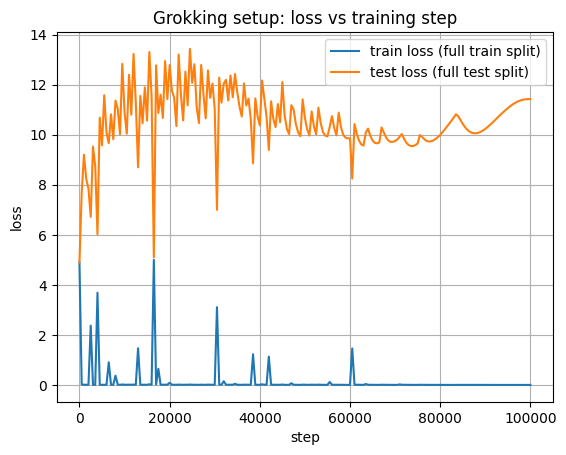

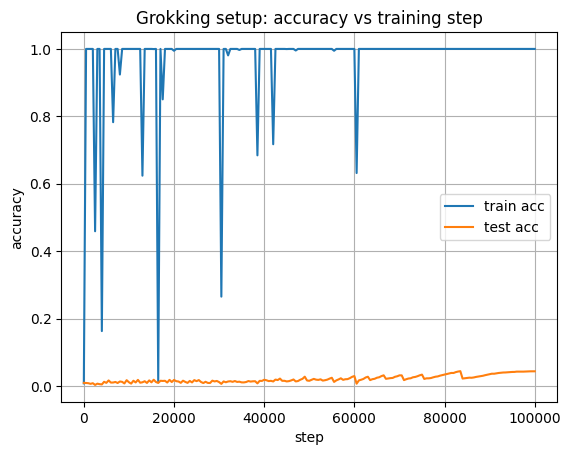

In [32]:
train2(cfg4, seed=0)